# attrib-EDITS · edits_l4 — on-manifold vs off-manifold (the novelty)

An edit that flips the model but produces an unnatural sequence is not a useful design hypothesis. We add an **ESM plausibility penalty inside the search loop** and compare: the constrained search should trade a few more edits for far more realistic substitutions.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "edits"))   # for `import edits_common`
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from edits_common import DEMO_SEQ, greedy_counterfactual, edit_metrics
off = greedy_counterfactual(DEMO_SEQ, target_drop=8.0, plausibility_weight=0.0)
on  = greedy_counterfactual(DEMO_SEQ, target_drop=8.0, plausibility_weight=1.0)
print('off-manifold:', edit_metrics(off))
print(' edits:', [f'{w}{p}{m}' for p, w, m in off['edits']])
print('on-manifold :', edit_metrics(on))
print(' edits:', [f'{w}{p}{m}' for p, w, m in on['edits']])

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

off-manifold: {'validity': True, 'proximity_n_edits': 2, 'plausibility': -11.671956062316895, 'fitness_drop': 11.839676856994629}
 edits: ['M0W', 'D45W']
on-manifold : {'validity': True, 'proximity_n_edits': 6, 'plausibility': -6.761209011077881, 'fitness_drop': 10.48107624053955}
 edits: ['M0A', 'G8A', 'T52A', 'Y44A', 'T50A', 'A23C']


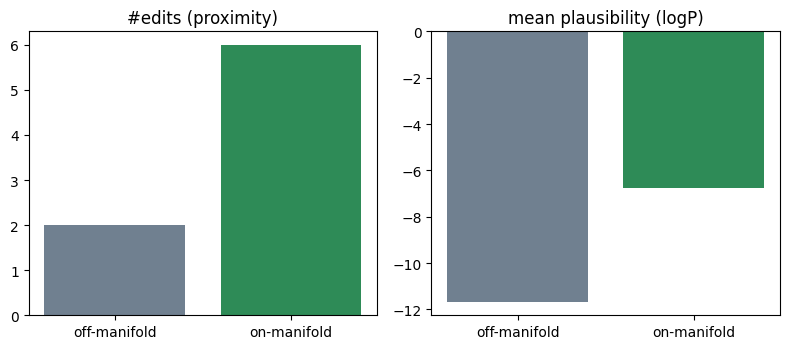

In [3]:
import matplotlib.pyplot as plt
labels = ['off-manifold', 'on-manifold']
nedits = [off['n_edits'], on['n_edits']]
plaus = [off['mean_plausibility'], on['mean_plausibility']]
fig, ax = plt.subplots(1, 2, figsize=(8, 3.6))
ax[0].bar(labels, nedits, color=['slategray', 'seagreen']); ax[0].set_title('#edits (proximity)')
ax[1].bar(labels, plaus, color=['slategray', 'seagreen']); ax[1].set_title('mean plausibility (logP)')
plt.tight_layout(); plt.show()

### Things to experiment with
- Sweep `plausibility_weight` and trace the proximity↔plausibility Pareto front.
- The on-manifold constraint is what makes a counterfactual a *falsifiable* design hypothesis.